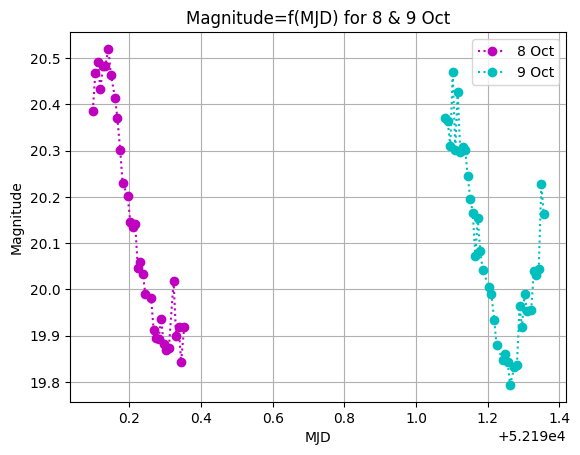

In [1]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

# Read data from file 1
mag1 = []
mjd1 = []

with open('8_OCT_mag_mjd.txt', 'r') as file:
    for line in file:
        x, y = map(float, line.split())
        mag1.append(x)
        mjd1.append(y)

# Read data from file 2
mag2 = []
mjd2 = []

with open('9_OCT_mag_mjd.txt', 'r') as file:
    for line in file:
        x, y = map(float, line.split())
        mag2.append(x)
        mjd2.append(y)
Mag = mag1+mag2
MJD = mjd1+ mjd2
# Plot the data
plt.plot(mjd1, mag1, 'mo:', label='8 Oct')
plt.plot(mjd2, mag2, 'co:', label='9 Oct' )

# Customize the plot
plt.xlabel('MJD')
plt.ylabel('Magnitude')
plt.title('Magnitude=f(MJD) for 8 & 9 Oct')
plt.legend()
plt.grid()

#plt.savefig("f(MJD).pdf")
# Show the plot
plt.show()


period by using the frequency of light curve :  15:29:01.731388
the coef for the sin function are: [ 0.27770677  3.10001135  0.72637447 20.12464653]


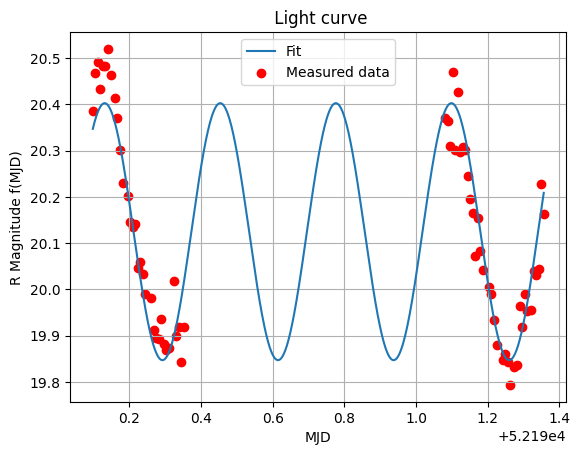

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import log10
from scipy.optimize import curve_fit
import datetime
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks

def sin1 (t,a,f,phi,c):
    return a*np.sin(2*np.pi*(f)*(t+phi)) +c

mjdT = np.linspace(min(MJD),max(MJD), 1000)
#mjdT = np.linspace(min(MJD),max(MJD), len(Mag))

coef, pov = curve_fit(sin1, MJD, Mag, p0=[30,3.1,1, Mag[0]] ,method = 'lm')

freq_curve = coef[1]

Period = (1/freq_curve)*2

print('period by using the frequency of light curve : ', datetime.timedelta(days= Period))
print("the coef for the sin function are:", coef)
plt.plot(mjdT, sin1(mjdT, *coef), label='Fit')
plt.scatter(MJD, Mag, label= "Measured data" , color='r')
#plt.plot(MJD, Mag, 'go:',label= "Measured data")
plt.xlabel("MJD")
plt.ylabel("R Magnitude f(MJD)")
plt.title (" Light curve")
plt.legend()
plt.grid()

#plt.savefig("light_curve.pdf")
plt.show()
